# 02_Classification_Metrics.ipynb

# Section 1 — Introduction

---

# What are Classification Metrics?

After training a classification model, we need to measure **how well it classifies data into the correct classes**.

Classification metrics compare the **actual class labels** with the **predicted class labels** and quantify the model's performance.

Without evaluation metrics, we cannot determine:

* Whether the model is making correct predictions.
* Which types of mistakes it makes.
* Whether one classifier performs better than another.

---

# Why do we need Classification Metrics?

Consider a disease prediction model.

| Patient | Actual  | Predicted |
| ------- | ------- | --------- |
| 1       | Disease | Disease   |
| 2       | Disease | Healthy   |
| 3       | Healthy | Healthy   |
| 4       | Healthy | Disease   |

Accuracy alone tells us **how many predictions were correct**, but it doesn't tell us **which mistakes were made**.

In many real-world problems, different mistakes have different costs.

Examples:

| Problem          | More Serious Mistake                 |
| ---------------- | ------------------------------------ |
| Cancer Detection | Predicting a sick patient as healthy |
| Fraud Detection  | Missing a fraudulent transaction     |
| Spam Detection   | Marking an important email as spam   |

This is why we use multiple classification metrics.

---

# Mathematical Intuition

A classification model produces predictions like:

```text id="4nl9q8"
Actual:

[1 0 1 1 0]

Predicted:

[1 1 1 0 0]
```

Each prediction falls into one of four categories.

| Actual   | Predicted | Category            |
| -------- | --------- | ------------------- |
| Positive | Positive  | True Positive (TP)  |
| Negative | Negative  | True Negative (TN)  |
| Negative | Positive  | False Positive (FP) |
| Positive | Negative  | False Negative (FN) |

These four values form the foundation of almost every classification metric.

---

# Confusion Matrix

The **Confusion Matrix** summarizes all predictions.

|                     | Predicted Positive  | Predicted Negative  |
| ------------------- | ------------------- | ------------------- |
| **Actual Positive** | True Positive (TP)  | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN)  |

Understanding these four values is essential because metrics like Accuracy, Precision, Recall, and F1 Score are all derived from them.

---

# Understanding the Four Outcomes

| Term                | Meaning                        |
| ------------------- | ------------------------------ |
| True Positive (TP)  | Correctly predicted positive   |
| True Negative (TN)  | Correctly predicted negative   |
| False Positive (FP) | Incorrectly predicted positive |
| False Negative (FN) | Incorrectly predicted negative |

Example (Disease Detection):

| Actual  | Predicted | Result |
| ------- | --------- | ------ |
| Disease | Disease   | TP     |
| Healthy | Healthy   | TN     |
| Healthy | Disease   | FP     |
| Disease | Healthy   | FN     |

---

# Major Classification Metrics

| Metric    | Measures                             | Best Value |
| --------- | ------------------------------------ | ---------- |
| Accuracy  | Overall correctness                  | 1          |
| Precision | Correctness of positive predictions  | 1          |
| Recall    | Ability to find actual positives     | 1          |
| F1 Score  | Balance between Precision and Recall | 1          |
| ROC AUC   | Ability to separate classes          | 1          |
| Log Loss  | Quality of predicted probabilities   | 0          |

---

# When Should Each Metric Be Used?

| Situation                               | Recommended Metric    |
| --------------------------------------- | --------------------- |
| Balanced dataset                        | Accuracy              |
| Imbalanced dataset                      | Precision, Recall, F1 |
| Missing positives is expensive          | Recall                |
| False positives are expensive           | Precision             |
| Need one balanced metric                | F1 Score              |
| Compare classifiers using probabilities | ROC AUC               |

---

# Accuracy Can Be Misleading

Consider a fraud detection dataset.

| Class   | Samples |
| ------- | ------: |
| Genuine |     990 |
| Fraud   |      10 |

Suppose the model predicts:

```text id="qofkrh"
Every transaction is Genuine
```

Accuracy:

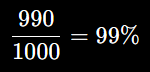

The model has **99% accuracy** but **fails to detect every fraud case**.

This demonstrates why accuracy alone is often insufficient, especially for imbalanced datasets.

---

# Characteristics of Common Metrics

| Metric    | Uses TP | Uses TN | Uses FP | Uses FN |
| --------- | ------- | ------- | ------- | ------- |
| Accuracy  | ✅       | ✅       | ✅       | ✅       |
| Precision | ✅       | ❌       | ✅       | ❌       |
| Recall    | ✅       | ❌       | ❌       | ✅       |
| F1 Score  | ✅       | ❌       | ✅       | ✅       |

---

# Applications

| Domain        | Example             |
| ------------- | ------------------- |
| Healthcare    | Disease diagnosis   |
| Finance       | Fraud detection     |
| Banking       | Loan approval       |
| Email         | Spam detection      |
| Cybersecurity | Intrusion detection |
| Manufacturing | Defect detection    |

---

# Comparison of Metrics

| Metric    | Best Value | Higher/Lower Better | Handles Imbalanced Data Well? |
| --------- | ---------: | ------------------- | ----------------------------- |
| Accuracy  |          1 | Higher              | ❌ No                          |
| Precision |          1 | Higher              | ✅ Yes                         |
| Recall    |          1 | Higher              | ✅ Yes                         |
| F1 Score  |          1 | Higher              | ✅ Yes                         |
| ROC AUC   |          1 | Higher              | ✅ Yes                         |
| Log Loss  |          0 | Lower               | Depends on context            |

---

# Metrics Available in `sklearn.metrics`

| Metric                | Function                  |
| --------------------- | ------------------------- |
| Accuracy              | `accuracy_score()`        |
| Precision             | `precision_score()`       |
| Recall                | `recall_score()`          |
| F1 Score              | `f1_score()`              |
| Confusion Matrix      | `confusion_matrix()`      |
| Classification Report | `classification_report()` |
| ROC Curve             | `roc_curve()`             |
| ROC AUC               | `roc_auc_score()`         |
| Log Loss              | `log_loss()`              |

---

# Key Takeaways

* Classification metrics evaluate **how well a model predicts class labels**.
* All major metrics are derived from **TP, TN, FP, and FN**.
* **Accuracy** is suitable for balanced datasets but can be misleading for imbalanced datasets.
* **Precision**, **Recall**, and **F1 Score** are essential for evaluating imbalanced classification problems.
* **ROC AUC** evaluates the model's ability to distinguish between classes across different thresholds.
* Using multiple metrics provides a more complete assessment than relying on accuracy alone.

# Section 2 — Import & Functions

Like regression metrics, **classification metrics are functions**, not estimator classes.

So there is:

* ❌ No constructor
* ❌ No model object
* ✅ Import the required metric function and use it directly.

---

# Import

```python
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    log_loss
)
```

---

# Available Classification Metric Functions

| Function                  | Purpose                                 | Best Value       |
| ------------------------- | --------------------------------------- | ---------------- |
| `accuracy_score()`        | Overall prediction accuracy             | 1                |
| `precision_score()`       | Correct positive predictions            | 1                |
| `recall_score()`          | Finds actual positives                  | 1                |
| `f1_score()`              | Balance of Precision & Recall           | 1                |
| `confusion_matrix()`      | Counts TP, FP, TN, FN                   | Perfect diagonal |
| `classification_report()` | Summary of metrics                      | Higher is better |
| `roc_curve()`             | Computes ROC curve points               | —                |
| `roc_auc_score()`         | Area Under ROC Curve                    | 1                |
| `log_loss()`              | Measures probability prediction quality | 0                |

---

# Common Parameters

Most metric functions follow this format:

```python
metric(y_true, y_pred)
```

| Parameter | Description            |
| --------- | ---------------------- |
| `y_true`  | Actual class labels    |
| `y_pred`  | Predicted class labels |

Example:

```python
accuracy = accuracy_score(y_test, y_pred)
```

Some functions require **predicted probabilities** instead of predicted labels.

Example:

```python
y_prob = model.predict_proba(X_test)[:, 1]
```

We'll see those later.

---

# 1. accuracy_score()

Calculates the percentage of correctly classified samples.

## Syntax

```python
accuracy_score(
    y_true,
    y_pred,
    *,
    normalize=True,
    sample_weight=None
)
```

### Important Parameters

| Parameter       | Default | Description                   |
| --------------- | ------- | ----------------------------- |
| `y_true`        | —       | Actual labels                 |
| `y_pred`        | —       | Predicted labels              |
| `normalize`     | `True`  | Return accuracy as a fraction |
| `sample_weight` | `None`  | Weight samples                |

---

### Returns

```python
float
```

Example

```python
accuracy = accuracy_score(
    y_test,
    y_pred
)
```

Output

```text
0.9737
```

---

# 2. precision_score()

Measures how many predicted positives are actually positive.

## Syntax

```python
precision_score(
    y_true,
    y_pred,
    *,
    labels=None,
    pos_label=1,
    average='binary',
    sample_weight=None,
    zero_division='warn'
)
```

### Important Parameters

| Parameter       | Default    | Description                  |
| --------------- | ---------- | ---------------------------- |
| `y_true`        | —          | Actual labels                |
| `y_pred`        | —          | Predicted labels             |
| `average`       | `'binary'` | Averaging strategy           |
| `pos_label`     | `1`        | Positive class               |
| `zero_division` | `'warn'`   | Handles divide-by-zero cases |

Example

```python
precision = precision_score(
    y_test,
    y_pred
)
```

---

# 3. recall_score()

Measures how many actual positives are correctly identified.

## Syntax

```python
recall_score(
    y_true,
    y_pred,
    *,
    labels=None,
    pos_label=1,
    average='binary',
    sample_weight=None,
    zero_division='warn'
)
```

The parameters are almost identical to `precision_score()`.

Example

```python
recall = recall_score(
    y_test,
    y_pred
)
```

---

# 4. f1_score()

Computes the harmonic mean of Precision and Recall.

## Syntax

```python
f1_score(
    y_true,
    y_pred,
    *,
    labels=None,
    pos_label=1,
    average='binary',
    sample_weight=None,
    zero_division='warn'
)
```

Example

```python
f1 = f1_score(
    y_test,
    y_pred
)
```

---

# 5. confusion_matrix()

Returns the confusion matrix.

## Syntax

```python
confusion_matrix(
    y_true,
    y_pred,
    *,
    labels=None,
    sample_weight=None,
    normalize=None
)
```

### Returns

A NumPy array.

Example

```python
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)
```

Output

```text
[[41  2]
 [ 1 70]]
```

---

# 6. classification_report()

Generates a complete performance report.

## Syntax

```python
classification_report(
    y_true,
    y_pred,
    *,
    labels=None,
    target_names=None,
    digits=2,
    output_dict=False,
    zero_division='warn'
)
```

Example

```python
print(
    classification_report(
        y_test,
        y_pred
    )
)
```

Example output

```text
              precision    recall    f1-score

0               0.98       0.95       0.96
1               0.97       0.99       0.98

accuracy                             0.97
```

---

# 7. roc_curve()

Computes the ROC curve.

Unlike previous metrics, it requires **predicted probabilities**.

## Syntax

```python
roc_curve(
    y_true,
    y_score,
    *,
    pos_label=None
)
```

Notice:

```python
y_score
```

instead of

```python
y_pred
```

Example

```python
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)
```

Returns

```python
False Positive Rate

True Positive Rate

Thresholds
```

---

# 8. roc_auc_score()

Calculates the Area Under the ROC Curve.

## Syntax

```python
roc_auc_score(
    y_true,
    y_score,
    *,
    average='macro'
)
```

Example

```python
auc = roc_auc_score(
    y_test,
    y_prob
)
```

Output

```text
0.99
```

---

# 9. log_loss()

Measures the quality of predicted probabilities.

## Syntax

```python
log_loss(
    y_true,
    y_pred
)
```

Here,

```python
y_pred
```

should contain **predicted probabilities**, not class labels.

Example

```python
loss = log_loss(
    y_test,
    y_prob
)
```

Smaller values indicate better probability predictions.

---

# Return Values Summary

| Function                  | Returns                                         |
| ------------------------- | ----------------------------------------------- |
| `accuracy_score()`        | Float                                           |
| `precision_score()`       | Float                                           |
| `recall_score()`          | Float                                           |
| `f1_score()`              | Float                                           |
| `confusion_matrix()`      | NumPy Array                                     |
| `classification_report()` | String (or Dictionary)                          |
| `roc_curve()`             | Three NumPy Arrays (`fpr`, `tpr`, `thresholds`) |
| `roc_auc_score()`         | Float                                           |
| `log_loss()`              | Float                                           |

---

# Which Function Should You Use?

| Goal                         | Function                  |
| ---------------------------- | ------------------------- |
| Overall accuracy             | `accuracy_score()`        |
| Minimize false positives     | `precision_score()`       |
| Minimize false negatives     | `recall_score()`          |
| Balance precision and recall | `f1_score()`              |
| View TP, FP, TN, FN          | `confusion_matrix()`      |
| Full evaluation summary      | `classification_report()` |
| ROC analysis                 | `roc_curve()`             |
| Compare classifiers          | `roc_auc_score()`         |
| Evaluate probabilities       | `log_loss()`              |

---

# Recommended Metrics for Most Projects

For most binary classification projects, these five are enough:

```python
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
```

If you're comparing models using probability outputs, also include:

```python
roc_auc_score
classification_report
```

---

## Interview Tip ⭐

A very common interview question is:

> **Why do `roc_curve()` and `roc_auc_score()` use `y_score` instead of `y_pred`?**

**Answer:**
Because ROC evaluates the model across **all possible classification thresholds**, which requires the **predicted probabilities (or decision scores)**, not the final class labels (0 or 1).

# Section 3 — Metric Functions (Deep Dive)

In the previous section, we learned **how to import** the metric functions.

In this section, we'll understand:

* What each metric measures
* How it is calculated
* How to interpret it
* When to use it
* Advantages & limitations

We'll use the same example throughout.

---

# Example Data

```python
y_true = [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]

y_pred = [1, 1, 0, 1, 1, 0, 0, 0, 1, 0]
```

Let's first build the confusion matrix.

---

# 1. Confusion Matrix ⭐⭐⭐⭐⭐

The confusion matrix is the **foundation of all classification metrics**.

Every major metric (Accuracy, Precision, Recall, F1 Score) is calculated using these four values.

---

## Confusion Matrix

|                     | Predicted Positive | Predicted Negative |
| ------------------- | ------------------ | ------------------ |
| **Actual Positive** | TP                 | FN                 |
| **Actual Negative** | FP                 | TN                 |

---

## Meaning of Each Term

| Term | Meaning                                  |
| ---- | ---------------------------------------- |
| TP   | Correctly predicted positive             |
| TN   | Correctly predicted negative             |
| FP   | Predicted positive but actually negative |
| FN   | Predicted negative but actually positive |

---

## Example

Using our data:

```text
y_true

1 1 1 1 0 0 0 0 0 0

y_pred

1 1 0 1 1 0 0 0 1 0
```

Count each category.

| Sample | Actual | Predicted | Result |
| ------ | ------ | --------- | ------ |
| 1      | 1      | 1         | TP     |
| 2      | 1      | 1         | TP     |
| 3      | 1      | 0         | FN     |
| 4      | 1      | 1         | TP     |
| 5      | 0      | 1         | FP     |
| 6      | 0      | 0         | TN     |
| 7      | 0      | 0         | TN     |
| 8      | 0      | 0         | TN     |
| 9      | 0      | 1         | FP     |
| 10     | 0      | 0         | TN     |

Final counts:

```text
TP = 3

TN = 4

FP = 2

FN = 1
```

---

## In scikit-learn

```python
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)
```

Output

```text
[[4 2]
 [1 3]]
```

---

## How to Read It

Scikit-learn returns

```text
[[TN FP]
 [FN TP]]
```

So

```text
[[4 2]
 [1 3]]
```

means

|          | Predicted 0 | Predicted 1 |
| -------- | ----------- | ----------- |
| Actual 0 | 4           | 2           |
| Actual 1 | 1           | 3           |

---

## Visualization

```python
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred
)
```

This is the standard way to visualize a confusion matrix.

---

## When to Use

Always.

Before looking at any classification metric, inspect the confusion matrix.

---

# 2. Accuracy ⭐⭐⭐⭐

## What is Accuracy?

Accuracy measures the **overall percentage of correct predictions**.

---

## Formula

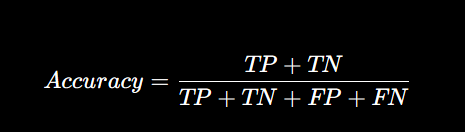

---

## Using Our Example

```
TP = 3

TN = 4

FP = 2

FN = 1
```

[
Accuracy=\frac{3+4}{10}=0.7
]

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_true,
    y_pred
)

print(accuracy)
```

Output

```text
0.7
```

---

## Interpretation

The model correctly classified

```text
70%
```

of all samples.

---

## Properties

| Property             | Value |
| -------------------- | ----- |
| Best Value           | 1     |
| Higher is Better     | ✅     |
| Range                | 0–1   |
| Uses all four values | ✅     |

---

## Advantages

* Easy to understand.
* Good for balanced datasets.
* Most commonly reported metric.

---

## Limitations

Accuracy becomes misleading on **imbalanced datasets**.

Example

| Class    | Samples |
| -------- | ------- |
| Negative | 990     |
| Positive | 10      |

Predicting

```text
Everything Negative
```

gives

```text
99% Accuracy
```

while completely missing the positive class.

---

## When to Use

* Balanced datasets.
* Similar importance for all classes.

---

# 3. Precision ⭐⭐⭐⭐⭐

## What is Precision?

Precision answers:

> **Of all samples predicted as Positive, how many were actually Positive?**

---

## Formula

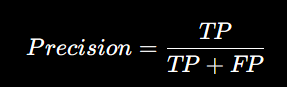

---

Using our example

```
TP = 3

FP = 2
```

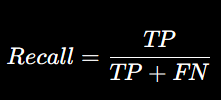

```python
from sklearn.metrics import precision_score

precision = precision_score(
    y_true,
    y_pred
)

print(precision)
```

Output

```text
0.6
```

---

## Interpretation

Among everything predicted as positive,

```text
60%
```

was actually positive.

---

## When is Precision Important?

When **False Positives are expensive**.

Examples:

| Problem        | Why Precision?                          |
| -------------- | --------------------------------------- |
| Spam Detection | Don't classify important emails as spam |
| Loan Approval  | Don't approve risky applicants          |
| Face Unlock    | Don't unlock for the wrong person       |

---

## Properties

| Property         | Value  |
| ---------------- | ------ |
| Best Value       | 1      |
| Higher is Better | ✅      |
| Uses             | TP, FP |

---

# 4. Recall ⭐⭐⭐⭐⭐

## What is Recall?

Recall answers:

> **Of all actual Positive samples, how many did the model correctly identify?**

---

## Formula

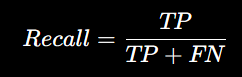

---

Using our example

```
TP = 3

FN = 1
```

[
Recall=\frac{3}{4}=0.75
]

```python
from sklearn.metrics import recall_score

recall = recall_score(
    y_true,
    y_pred
)

print(recall)
```

Output

```text
0.75
```

---

## Interpretation

The model successfully found

```text
75%
```

of all positive cases.

---

## When is Recall Important?

When **False Negatives are expensive**.

Examples:

| Problem          | Why Recall?                         |
| ---------------- | ----------------------------------- |
| Cancer Detection | Missing a patient is dangerous      |
| Fraud Detection  | Missing fraud causes financial loss |
| Fire Detection   | Missing fire can be catastrophic    |

---

## Properties

| Property         | Value  |
| ---------------- | ------ |
| Best Value       | 1      |
| Higher is Better | ✅      |
| Uses             | TP, FN |

---

This completes the first half of **Section 3**.

The remaining part:

* **F1 Score**
* **ROC Curve**
* **ROC AUC**
* **Log Loss**
* **Classification Report**
* **Macro Average vs Weighted Average**

# Section 3 (Continued) — Metric Functions (Deep Dive)

---

# 5. F1 Score ⭐⭐⭐⭐⭐

## What is F1 Score?

F1 Score combines **Precision** and **Recall** into a single metric.

It is useful when **both False Positives and False Negatives are important**.

---

## Formula

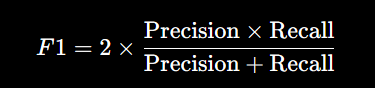

Notice that it uses the **Harmonic Mean**, not the Arithmetic Mean.

---

## Why Harmonic Mean?

Suppose

| Precision | Recall |
| --------- | ------ |
| 1.0       | 0.2    |

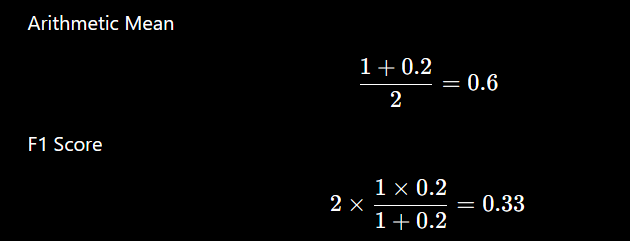

The harmonic mean penalizes a model if either Precision or Recall is low.

---

## Using Our Example

Previously we calculated

```text id="b17q6d"
Precision = 0.60

Recall = 0.75
```

Therefore,

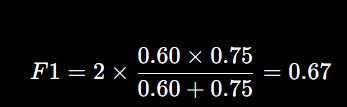

```python
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)

print(f1)
```

Output

```text
0.67
```

---

## Interpretation

The model achieves a balanced score of **67%** considering both Precision and Recall.

---

## Properties

| Property         | Value      |
| ---------------- | ---------- |
| Best Value       | 1          |
| Higher is Better | ✅          |
| Uses             | TP, FP, FN |
| Uses TN          | ❌ No       |

---

## When to Use

Use F1 Score when:

* Dataset is imbalanced
* Precision and Recall are equally important
* Need one overall metric

Examples:

* Medical diagnosis
* Fraud detection
* Spam detection

---

# Precision vs Recall vs F1

| Metric    | Focus                  |
| --------- | ---------------------- |
| Precision | Reduce False Positives |
| Recall    | Reduce False Negatives |
| F1 Score  | Balance both           |

---

# 6. ROC Curve ⭐⭐⭐⭐

## What is ROC Curve?

ROC stands for

```text
Receiver Operating Characteristic
```

It shows how the classifier performs at **different classification thresholds**.

Unlike Accuracy or F1 Score, ROC does **not** evaluate the model at only one threshold (0.5).

---

## Axes

| Axis   | Meaning                     |
| ------ | --------------------------- |
| X-axis | False Positive Rate (FPR)   |
| Y-axis | True Positive Rate (Recall) |

---

## Formulas

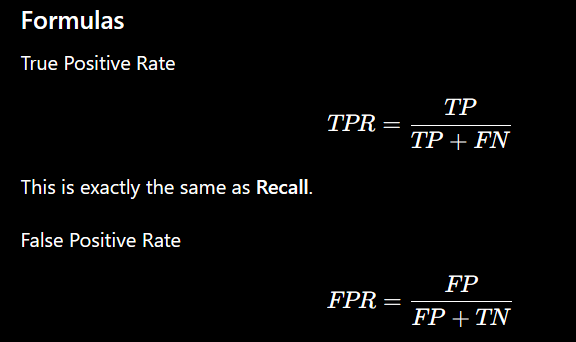

---

## Why ROC Uses Probabilities

Suppose probabilities are

```text
0.95
0.88
0.74
0.61
0.48
0.30
```

Changing the threshold

```text
0.9

0.8

0.7

0.5

0.3
```

changes TP, FP, TN and FN.

ROC evaluates performance across **all thresholds**, not just 0.5.

Therefore it requires

```python
model.predict_proba()
```

instead of

```python
model.predict()
```

---

## Example

```python
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)
```

Returns

* False Positive Rate
* True Positive Rate
* Thresholds

---

# 7. ROC AUC ⭐⭐⭐⭐⭐

## What is ROC AUC?

ROC AUC means

```text
Area Under ROC Curve
```

Instead of looking at the entire ROC graph, it summarizes the performance using a single number.

---

## Range

| AUC     | Interpretation     |
| ------- | ------------------ |
| 1.0     | Perfect classifier |
| 0.9–1.0 | Excellent          |
| 0.8–0.9 | Very Good          |
| 0.7–0.8 | Good               |
| 0.5     | Random guessing    |
| <0.5    | Worse than random  |

---

## Example

```python
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob
)

print(auc)
```

Output

```text
0.98
```

---

## Interpretation

The classifier has an excellent ability to distinguish between positive and negative classes.

---

## When to Use

* Compare classifiers
* Imbalanced datasets
* Probability-based evaluation

---

# 8. Log Loss ⭐⭐⭐

## What is Log Loss?

Log Loss evaluates **how good the predicted probabilities are**.

Unlike Accuracy,

it penalizes

* Wrong predictions
* Overconfident wrong predictions

---

Example

Prediction

```text
0.99
```

Actual

```text
1
```

Very good.

Prediction

```text
0.01
```

Actual

```text
1
```

Very bad.

Log Loss gives a large penalty.

---

## Properties

| Property           | Value |
| ------------------ | ----- |
| Best Value         | 0     |
| Lower is Better    | ✅     |
| Uses Probabilities | ✅     |

---

## Example

```python
from sklearn.metrics import log_loss

loss = log_loss(
    y_test,
    y_prob
)

print(loss)
```

---

## When to Use

* Probability prediction
* Neural Networks
* Logistic Regression evaluation

---

# 9. Classification Report ⭐⭐⭐⭐⭐

Instead of calculating every metric separately,

Scikit-learn can generate all important metrics together.

---

## Example

```python
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)
```

Output

```text
              precision    recall    f1-score    support

0               0.95        0.93       0.94        43

1               0.97        0.98       0.98        71

accuracy                               0.96       114

macro avg      0.96        0.96       0.96       114

weighted avg   0.96        0.96       0.96       114
```

---

## Understanding Each Column

| Column    | Meaning                                 |
| --------- | --------------------------------------- |
| Precision | Correctness of positive predictions     |
| Recall    | Percentage of actual positives detected |
| F1-score  | Balance between Precision and Recall    |
| Support   | Number of actual samples in that class  |

---

## Macro Average

Computes the metric for every class independently.

Then simply averages them.

Example

```text
Class 0

Precision = 0.90

Class 1

Precision = 0.70
```

Macro Average

```text
(0.90 + 0.70)/2

=

0.80
```

Every class gets **equal importance**.

---

## Weighted Average

Again computes every class separately.

But now weights them according to class size.

Example

```text
Class 0

900 samples

Precision = 0.90

Class 1

100 samples

Precision = 0.70
```

Weighted Average becomes much closer to

```text
0.90
```

because Class 0 has many more samples.

---

## Macro vs Weighted

| Macro Average                  | Weighted Average             |
| ------------------------------ | ---------------------------- |
| Equal weight to every class    | Weight based on class size   |
| Better for imbalanced datasets | Better overall summary       |
| Small classes matter equally   | Large classes influence more |

---

# Summary Comparison

| Metric    | Best Value | Higher/Lower Better | Uses Probabilities |
| --------- | ---------: | ------------------- | ------------------ |
| Accuracy  |          1 | Higher              | ❌                  |
| Precision |          1 | Higher              | ❌                  |
| Recall    |          1 | Higher              | ❌                  |
| F1 Score  |          1 | Higher              | ❌                  |
| ROC AUC   |          1 | Higher              | ✅                  |
| Log Loss  |          0 | Lower               | ✅                  |

---

# Which Metrics Should You Report?

For most binary classification projects, report:

```python
Accuracy
Precision
Recall
F1 Score
ROC AUC
Confusion Matrix
Classification Report
```

This combination provides a comprehensive evaluation of classification performance and is the standard set used in machine learning projects, Kaggle competitions, and technical interviews.

---

## Classification Metrics — Interview Questions with Answers

---

### 1. What is a Confusion Matrix?

**Answer:**
A Confusion Matrix is a table that summarizes a classification model's predictions by comparing the actual labels with the predicted labels. It contains four values: **True Positive (TP), True Negative (TN), False Positive (FP), and False Negative (FN)**. Most classification metrics are derived from these values.

---

### 2. Explain True Positive (TP), True Negative (TN), False Positive (FP), and False Negative (FN).

**Answer:**

| Term   | Meaning                                        |
| ------ | ---------------------------------------------- |
| **TP** | Correctly predicted Positive                   |
| **TN** | Correctly predicted Negative                   |
| **FP** | Incorrectly predicted Positive (Type I Error)  |
| **FN** | Incorrectly predicted Negative (Type II Error) |

---

### 3. What is Accuracy? When can it be misleading?

**Answer:**

Accuracy is the proportion of correctly classified samples.

[
\text{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
]

It becomes misleading on **imbalanced datasets** because a model can achieve high accuracy by always predicting the majority class while completely ignoring the minority class.

---

### 4. What is the difference between Precision and Recall?

**Answer:**

| Precision                                                   | Recall                                                              |
| ----------------------------------------------------------- | ------------------------------------------------------------------- |
| Of all predicted positives, how many are actually positive? | Of all actual positives, how many did the model correctly identify? |
| Focuses on False Positives                                  | Focuses on False Negatives                                          |

---

### 5. In which scenarios would you prioritize Precision over Recall?

**Answer:**

Prioritize **Precision** when **False Positives are expensive**.

Examples:

* Spam Detection
* Face Recognition
* Loan Approval

---

### 6. In which scenarios would you prioritize Recall over Precision?

**Answer:**

Prioritize **Recall** when **False Negatives are expensive**.

Examples:

* Cancer Detection
* Fraud Detection
* Fire Alarm Systems

---

### 7. What is the F1 Score, and why does it use the harmonic mean instead of the arithmetic mean?

**Answer:**

F1 Score is the harmonic mean of Precision and Recall.

[
F1=2\cdot\frac{Precision\times Recall}{Precision+Recall}
]

The harmonic mean penalizes models when either Precision or Recall is low, ensuring that both metrics must be high to achieve a high F1 Score.

---

### 8. What is ROC Curve? What do the X-axis and Y-axis represent?

**Answer:**

The ROC (Receiver Operating Characteristic) Curve evaluates a classifier across different classification thresholds.

* **X-axis:** False Positive Rate (FPR)
* **Y-axis:** True Positive Rate (TPR or Recall)

It shows the trade-off between correctly identifying positives and incorrectly predicting negatives as positives.

---

### 9. What is ROC AUC? How do you interpret values like 0.5, 0.8, and 1.0?

**Answer:**

ROC AUC (Area Under the ROC Curve) summarizes the ROC curve into a single value.

| AUC         | Interpretation     |
| ----------- | ------------------ |
| **1.0**     | Perfect classifier |
| **0.9–1.0** | Excellent          |
| **0.8–0.9** | Very good          |
| **0.7–0.8** | Good               |
| **0.5**     | Random guessing    |
| **< 0.5**   | Worse than random  |

Higher AUC indicates better class separation.

---

### 10. Why do `roc_curve()` and `roc_auc_score()` require predicted probabilities instead of class labels?

**Answer:**

ROC evaluates the classifier at **all possible thresholds**. Class labels (`predict()`) are generated using a single threshold (usually 0.5), whereas predicted probabilities (`predict_proba()`) or decision scores allow ROC to compute performance across every threshold.

---

### 11. What is Log Loss, and why does it penalize overconfident wrong predictions?

**Answer:**

Log Loss evaluates the quality of predicted probabilities.

* Lower Log Loss indicates better probability predictions.
* It heavily penalizes predictions that are both **incorrect** and **made with high confidence**.

Example:

* Predicting 0.99 for the correct class → Low loss.
* Predicting 0.99 for the wrong class → Very high loss.

---

### 12. What is the difference between `predict()` and `predict_proba()`?

**Answer:**

| `predict()`                | `predict_proba()`                        |
| -------------------------- | ---------------------------------------- |
| Returns class labels       | Returns class probabilities              |
| Output: `0`, `1`           | Output: `[0.2, 0.8]`                     |
| Used for final predictions | Used for ROC, Log Loss, threshold tuning |

---

### 13. What is the difference between Macro Average, Weighted Average, and Micro Average?

**Answer:**

| Average      | Description                                                                                                                                |
| ------------ | ------------------------------------------------------------------------------------------------------------------------------------------ |
| **Macro**    | Computes the metric for each class independently and takes the simple average. Every class has equal importance.                           |
| **Weighted** | Computes the metric for each class and averages them using the number of samples (support) as weights. Larger classes have more influence. |
| **Micro**    | Aggregates TP, FP, and FN across all classes before computing the metric. Suitable for overall performance in multiclass classification.   |

---

### 14. Which classification metrics are most appropriate for imbalanced datasets, and why?

**Answer:**

For imbalanced datasets, **Precision, Recall, F1 Score, and ROC AUC** are preferred because they focus on the model's ability to correctly identify the minority class, whereas Accuracy may be misleading.

---

### 15. Why is it recommended to report multiple classification metrics instead of only Accuracy?

**Answer:**

Each metric measures a different aspect of performance:

* **Accuracy:** Overall correctness
* **Precision:** Quality of positive predictions
* **Recall:** Ability to detect positives
* **F1 Score:** Balance between Precision and Recall
* **ROC AUC:** Overall discrimination ability across thresholds

Using multiple metrics provides a more complete and reliable evaluation of the classifier.
